In [74]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np


PAGE_WIDTH_CM=14

# 03_TRAIN_MODELS FIGURES

## Generalized performance
plot of $R^2$ for the individual labels (e.g., log U/Ks and log Ks/Ks), and the mean $R^2$ for the labels

In [116]:
# Define input file path
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename="nested-cv-results-full-886a995.pkl"
input_file_path = data_dir / filename


In [117]:
# read pickle file
with open(input_file_path, "rb") as f:  # "rb" means Read Binary
    results = pickle.load(f)

In [118]:
# get list of models
models=[m for m in list(results.keys()) if m[0]!="_"]
# get list of metrics
metrics=[m[5:] for m in list(results[list(results.keys())[0]].keys()) if m[:5]=='test_']
# get list of labels
labels=list(results['_meta']['label_names'])
label_scores=labels+['mean']

In [119]:
print(f'metrics: {metrics}')
print(f'label scores: {label_scores}')

metrics: ['r2', 'mse', 'rmse', 'mae']
label scores: ['u_ks', 'kh_ks', 'mean']


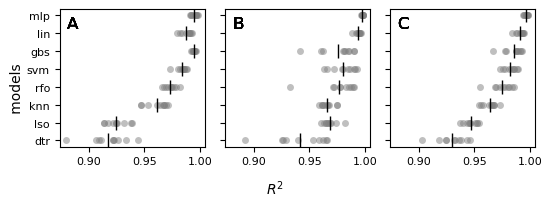

In [120]:
# figure settings and formats
fs_ytlab=8
fs_xtlab=8
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*14/14
fig_height_cm=5
ms_cv=5
ms_cv_mean=2*ms_cv
fig_dpi=600



#determine which metric to plot
metric='r2'
metric_label=r'$R^2$'

# determine order of models in y-axis, based on the mean label scores
mean_label_scores=[results[m][f'mean_test_{metric}'] for m in models]
sort_indices=np.argsort(mean_label_scores)
sorted_models=[models[i] for i in sort_indices]

# initialize figure
plt.close("all")
fig,axes=plt.subplots(nrows=1,ncols=len(label_scores),figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharey=True,sharex=True)
sp_label=['A','B','C','D']
# loop through sorted models
for sm, smodel in enumerate(sorted_models):
    # loop through label scores and figure axes
    for l,label in enumerate(label_scores):
        # get data to plot
        if 'mean' not in label:
            cv_scores=np.vstack(results[smodel][f'per_target_{metric}'])[:,l]
            mean_cv_score=np.mean(np.vstack(results[smodel][f'per_target_{metric}'])[:,l])
        else:
            cv_scores=results[smodel][f'test_{metric}']
            mean_cv_score=results[smodel][f'mean_test_{metric}']
        # plot data
        axes[l].plot(cv_scores,sm*np.ones(len(cv_scores)),'o',lw=0, mfc='0.5', alpha=0.5,mew=0,ms=ms_cv)
        axes[l].plot(mean_cv_score,sm,'k|',lw=2,ms=ms_cv_mean,mew=1)

        # set xticklabel fontsize
        axes[l].tick_params(labelsize=fs_xtlab)
        
        # add subplot label
        axes[l].text(0.05,0.95,sp_label[l],ha='left',va='top',fontsize=fs_annot,transform=axes[l].transAxes)

# rename y-axis tick labels
axes[0].set_yticks(np.arange(len(models)))
axes[0].set_yticklabels(sorted_models,fontsize=fs_ytlab)

# add x-axis label
fig.supxlabel(metric_label,fontsize=fs_xlab)
fig.supylabel('      models',fontsize=fs_xlab)
fig.tight_layout(pad=0.5)
fig.savefig(f'{filename.split(".")[0]}-generalized-{metric}.jpg',dpi=fig_dpi)
fig.savefig(f'{filename.split(".")[0]}-generalized-{metric}.svg')
# plt.close("all")


## Performance on unseen test set

In [89]:
# define input file path
data_dir = Path.cwd().parent / "outputs" / "features"
filename="features-all.pkl"
input_file_path = data_dir / filename

# read pickle file
with open(input_file_path, "rb") as f:  # "rb" means Read Binary
    features_df = pickle.load(f)


In [90]:
test_idx=results['_meta']['test_idx']
features_df.loc[test_idx]
features=results['_meta']['feature_names']
labels=results['_meta']['label_names']

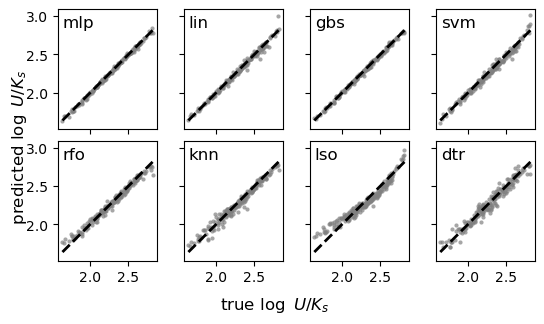

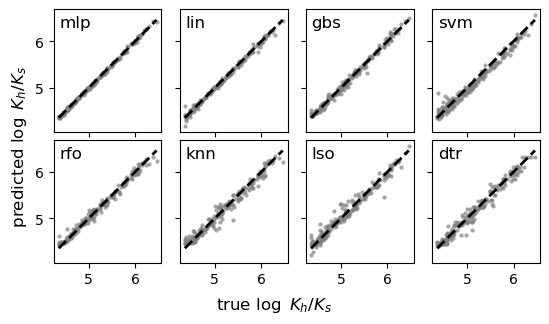

In [123]:
# figure settings and formats
fs_ytlab=8
fs_xtlab=8
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*14/14
fig_height_cm=8
ms=3
malpha=0.7
fig_dpi=600



plt.close("all")

fig1,axes1=plt.subplots(nrows=2,ncols=4,figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)
fig2,axes2=plt.subplots(nrows=2,ncols=4,figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)
# fig3,axes3=plt.subplots(nrows=2,ncols=4,figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)

axes1=axes1.flatten()
axes2=axes2.flatten()
# axes3=axes3.flatten()

for m,model in enumerate(sorted_models[::-1]):
    rgr=results[model]['final_model']['regressor']
    ypred=rgr.predict(features_df.loc[test_idx,features])
    ytrue=features_df.loc[test_idx,labels]
    axes1[m].plot(np.log10(ytrue.loc[:,labels[0]]),ypred[:,0],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    axes1[m].plot([np.min(np.log10(ytrue.loc[:,labels[0]])),np.max(np.log10(ytrue.loc[:,labels[0]]))],
                  [np.min(np.log10(ytrue.loc[:,labels[0]])),np.max(np.log10(ytrue.loc[:,labels[0]]))],
                  ls='--',c='k',lw=2)
    axes1[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes1[m].transAxes)

    axes2[m].plot(np.log10(ytrue.loc[:,labels[1]]),ypred[:,1],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    axes2[m].plot([np.min(np.log10(ytrue.loc[:,labels[1]])),np.max(np.log10(ytrue.loc[:,labels[1]]))],
                  [np.min(np.log10(ytrue.loc[:,labels[1]])),np.max(np.log10(ytrue.loc[:,labels[1]]))],
                  ls='--',c='k',lw=2)
    axes2[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes2[m].transAxes)


    # axes3[m].plot(np.log10(ytrue.loc[:,labels[2]]),ypred[:,2],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    # axes3[m].plot([np.min(np.log10(ytrue.loc[:,labels[2]])),np.max(np.log10(ytrue.loc[:,labels[2]]))],
    #               [np.min(np.log10(ytrue.loc[:,labels[2]])),np.max(np.log10(ytrue.loc[:,labels[2]]))],
    #               ls='--',c='k',lw=2)
    # axes3[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes3[m].transAxes)
    
    axes1[m].axis('scaled')
    axes2[m].axis('scaled')
    # axes3[m].axis('scaled')
fig1.supxlabel(fr'true $\log\ U/K_s$')
fig2.supxlabel(fr'true $\log\ K_h/K_s$')
# fig3.supxlabel(fr'true $\log\ K_s$')
fig1.supylabel(fr'     predicted $\log\ U/K_s$')
fig2.supylabel(fr'     predicted $\log\ K_h/K_s$')
# fig3.supylabel(fr'     predicted $\log\ K_s$')

fig2.tight_layout(pad=0.5)
fig1.tight_layout(pad=0.5)
# fig3.tight_layout(pad=0.5)

filename="nested-cv-results-full-886a995.pkl"
fig1.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[0]}.jpg',dpi=fig_dpi)
fig1.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[0]}.svg')
fig2.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[1]}.jpg',dpi=fig_dpi)
fig2.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[1]}.svg')
# fig3.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[2]}.jpg',dpi=fig_dpi)
# fig3.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[2]}.svg')
    

# 04_FEATURE_IMPORTANCE FIGURES